# Setup and Imports

In [23]:
# Standard library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch imports for neural networks
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Hugging Face datasets and transformers
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

# Data Loading and Initial Exploration

In [24]:
# Load the 'sms_spam' dataset from Hugging Face's datasets library
dataset = load_dataset("ucirvine/sms_spam")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['sms', 'label'],
        num_rows: 5574
    })
})


In [25]:
# Convert the training split of the dataset to a pandas DataFrame for easier manipulation
df = pd.DataFrame(dataset['train'])
display(df.head()) # Display the first few rows of the DataFrame
display(df.info()) # Display a summary of the DataFrame including data types and non-null counts

,sms,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...\n,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   sms     5574 non-null   object
 1   label   5574 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 87.2+ KB


None

In [26]:
# Extract 'sms' texts and 'label' integers from the dataset
texts = list(dataset["train"]["sms"])
labels = list(dataset["train"]["label"])

print("First 5 texts:", texts[:5])
print("First 5 labels:", labels[:5])
print("\nType of texts:", type(texts))
print("Type of labels:", type(labels))

First 5 texts: ['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...\n', 'Ok lar... Joking wif u oni...\n', "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's\n", 'U dun say so early hor... U c already then say...\n', "Nah I don't think he goes to usf, he lives around here though\n"]
First 5 labels: [0, 0, 1, 0, 0]

Type of texts: <class 'list'>
Type of labels: <class 'list'>


# Data Preparation - Class Imbalance Analysis

In [27]:
# Calculate the counts for each class (Ham and Spam)
class_counts = df['label'].value_counts()
print("Class Counts:\n", class_counts)
print("\nClass Percentages:\n", df['label'].value_counts(normalize=True) * 100) # Display class distribution as percentages

Class Counts:
 label
0    4827
1     747
Name: count, dtype: int64

Class Percentages:
 label
0    86.598493
1    13.401507
Name: proportion, dtype: float64


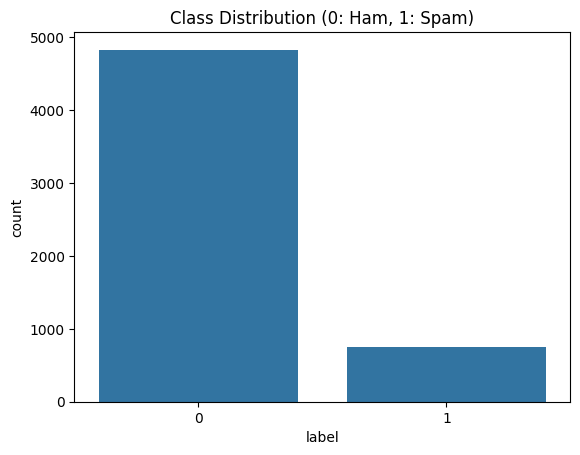

In [28]:
# Visualize the class distribution using a countplot
sns.countplot(data=df, x='label')
plt.title("Class Distribution (0: Ham, 1: Spam)") # Set the title of the plot
plt.show() # Display the plot

Class weights are multipliers applied directly to your loss function to fix this.

Instead of treating every mistake equally, you assign a higher penalty (weight) when the model misclassifies a rare class, and a lower penalty when it misclassifies a common class. If the model guesses "Ham" when the answer was actually "Spam", the loss function multiplies the error by a massive factor, forcing the neural network's weights to adjust drastically during backpropagation.

How to Calculate ThemThe most standard and robust mathematical formula for calculating inverse class weights is:$$w_c = \frac{N}{C \times N_c}$$
Here is what those variables mean:$w_c$ = The calculated weight for class $c$.$N$ = The total number of samples in your entire dataset.$C$ = The total number of unique classes (for binary classification, this is 2).$N_c$ = The number of samples specifically in class $c$.

In [29]:
# Calculate class weights to handle class imbalance
total_samples = len(df) # Total number of samples in the dataset
num_classes = len(class_counts) # Number of unique classes

weights = []
for i in range(num_classes):
    # Formula: Total Samples / (Number of Classes * Samples in Class)
    weight = total_samples / (num_classes * class_counts[i])
    weights.append(weight)

print(f"\nCalculated Class Weights: {weights}")


Calculated Class Weights: [np.float64(0.5773772529521441), np.float64(3.7309236947791167)]


# Data Preparation - Tokenization and Dataset Split


Token Length Statistics:
count    5574.000000
mean       25.401866
std        17.659101
min         3.000000
25%        12.000000
50%        20.000000
75%        36.000000
max       238.000000
Name: token_length, dtype: float64
90th Percentile: 49.0
95th Percentile: 55.0
99th Percentile: 79.26999999999953
Absolute Max: 238


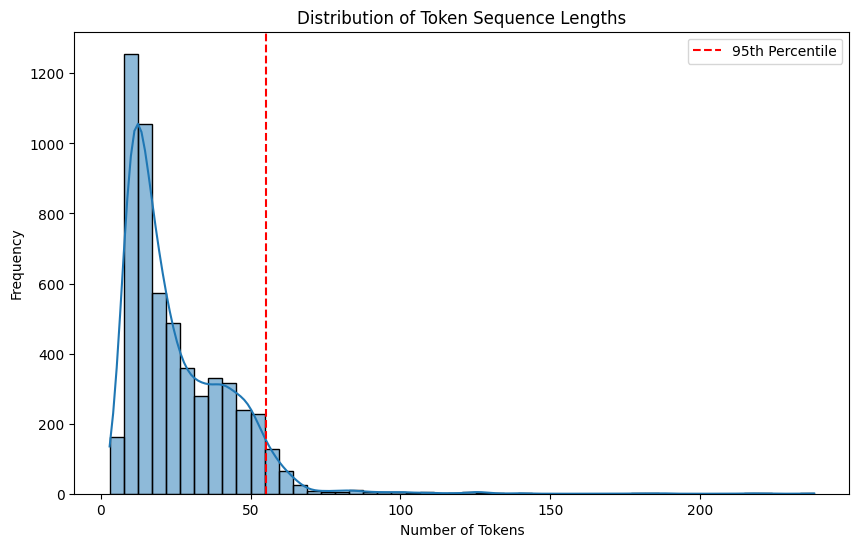

In [30]:
# Initialize the tokenizer for DistilBERT
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

tokenized_lengths = []
for text in df["sms"]:
  # Tokenize each text and get the length of the input_ids
  tokens = tokenizer(text , add_special_tokens=True)["input_ids"]
  tokenized_lengths.append(len(tokens))
df['token_length'] = tokenized_lengths # Add token lengths as a new column to the DataFrame

print("\nToken Length Statistics:")
print(df['token_length'].describe()) # Descriptive statistics of token lengths
print(f"90th Percentile: {np.percentile(df['token_length'], 90)}")
print(f"95th Percentile: {np.percentile(df['token_length'], 95)}")
print(f"99th Percentile: {np.percentile(df['token_length'], 99)}")
print(f"Absolute Max: {df['token_length'].max()}")

# Visualize the distribution of token lengths
plt.figure(figsize=(10, 6))
sns.histplot(df['token_length'], bins=50, kde=True)
plt.axvline(np.percentile(df['token_length'], 95), color='red', linestyle='dashed', label='95th Percentile')
plt.title("Distribution of Token Sequence Lengths")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [31]:
# Split the dataset into training and validation sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, # All text messages
    labels, # Corresponding labels
    test_size=0.2, # 20% of data for validation
    random_state=42 # For reproducibility
)

In [32]:
class SpamClassificationDataset(Dataset):
  # Custom Dataset class for handling spam classification data
  def __init__(self ,texts, labels, tokenizer_name="distilbert-base-uncased", max_length=79 ):
    self.texts = texts # List of text messages
    self.labels = labels # List of corresponding labels
    self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name) # Tokenizer for text processing
    self.max_length = max_length # Maximum sequence length for tokenization

  def __len__(self):
    return len(self.texts) # Return the total number of samples

  def __getitem__(self, idx):
    text = self.texts[idx] # Get text at current index
    label = self.labels[idx] # Get label at current index

    # Encode the text using the tokenizer
    encoding = self.tokenizer(
        text,
        add_special_tokens=True, # Add CLS and SEP tokens
        padding="max_length", # Pad to max_length
        truncation=True, # Truncate if longer than max_length
        max_length=self.max_length,
        return_tensors="pt" # Return PyTorch tensors
    )

    # Return a dictionary containing input_ids, attention_mask, and label
    return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "label": torch.tensor(label, dtype=torch.long)
        }

# Model Architecture

In [33]:
class TransformerSpamClassifier(nn.Module):
  # Transformer-based classifier for spam detection
  def __init__(self,model_name="distilbert-base-uncased", num_classes=2, dropout_rate=0.3):
    super(TransformerSpamClassifier, self).__init__()
    self.encoder = AutoModel.from_pretrained(model_name) # Load pre-trained transformer model
    self.dropout = nn.Dropout(dropout_rate) # Dropout layer for regularization
    # Linear classifier layer
    self.classifier = nn.Linear(self.encoder.config.hidden_size, num_classes)

  def forward(self, input_ids, attention_mask):
    # Pass input_ids and attention_mask through the transformer encoder
    outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
    # Extract the representation of the [CLS] token (first token) for classification
    cls_representation = outputs.last_hidden_state[:, 0, :]
    # Apply dropout
    pooled_output = self.dropout(cls_representation)
    # Pass through the classifier to get logits
    logits = self.classifier(pooled_output)

    return logits

# Training and Evaluation Functions

In [34]:
def setup_optimization(model, train_loader, epochs=3, base_lr=2e-5, class_weights=None):
  # Setup the loss function (criterion), optimizer, and learning rate scheduler
  if class_weights is not None:
      # Use weighted CrossEntropyLoss if class_weights are provided
      criterion = nn.CrossEntropyLoss(weight=class_weights)
  else:
      criterion = nn.CrossEntropyLoss()

  # AdamW optimizer with weight decay
  optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr ,weight_decay=0.01)
  total_steps = len(train_loader) * epochs # Total training steps
  num_warmup_steps = int(0.1 * total_steps) # Number of warmup steps (10% of total)

  # Linear learning rate scheduler with warmup
  scheduler =get_linear_schedule_with_warmup(
      optimizer ,
      num_warmup_steps ,
      total_steps

  )
  return criterion, optimizer, scheduler

In [35]:
def train_epoch(model, data_loader, criterion, optimizer, scheduler, device):
    model.train() # Set model to training mode
    total_loss = 0

    for batch in data_loader:
        optimizer.zero_grad() # Clear gradients from previous step

        # Move batch data to the specified device (CPU/GPU)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        # Forward pass to get logits
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels) # Calculate loss

        loss.backward() # Backward pass to compute gradients

        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step() # Update model parameters
        scheduler.step() # Update learning rate scheduler

        total_loss += loss.item() # Accumulate loss

    return total_loss / len(data_loader) # Return average loss for the epoch

In [36]:
def evaluate(model, data_loader, criterion, device):
    model.eval() # Set model to evaluation mode
    total_loss = 0
    correct_predictions = 0

    with torch.no_grad(): # Disable gradient calculations for inference
        for batch in data_loader:
            # Move batch data to the specified device (CPU/GPU)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            # Forward pass to get logits
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels) # Calculate loss
            total_loss += loss.item() # Accumulate loss

            preds = torch.argmax(logits, dim=1) # Get predicted class (index of max logit)
            correct_predictions += torch.sum(preds == labels) # Count correct predictions

    accuracy = correct_predictions.double() / len(data_loader.dataset) # Calculate accuracy
    return total_loss / len(data_loader), accuracy # Return average loss and accuracy

# Model Training

In [37]:
# Determine the device to use for training (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create dataset instances for training and validation
train_dataset = SpamClassificationDataset(train_texts, train_labels)
val_dataset = SpamClassificationDataset(val_texts, val_labels)

# Create DataLoaders for batching and shuffling data
train_loader = DataLoader(train_dataset , batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Convert class weights to a PyTorch tensor and move to the device
class_weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)
print(f"Class weights tensor: {class_weights_tensor}")

# Initialize the model and move it to the device
model = TransformerSpamClassifier()
model.to(device)

# Setup optimization components (criterion, optimizer, scheduler)
criterion, optimizer, scheduler = setup_optimization(
    model=model,
    train_loader=train_loader,
    epochs=3,
    class_weights=class_weights_tensor
)

epochs = 3 # Number of training epochs
for epoch in range(epochs):
    print(f"\n--- Starting Epoch {epoch + 1}/{epochs} ---")

    # Train for one epoch
    avg_train_loss = train_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device
    )
    print(f"Epoch {epoch + 1} complete! Average Training Loss: {avg_train_loss:.4f}")

    # Evaluate on the validation set
    avg_val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)
    print(f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

Using device: cuda
Class weights tensor: tensor([0.5774, 3.7309], device='cuda:0')


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Starting Epoch 1/3 ---
Epoch 1 complete! Average Training Loss: 0.1942
Validation Loss: 0.0485, Validation Accuracy: 0.9910

--- Starting Epoch 2/3 ---
Epoch 2 complete! Average Training Loss: 0.0638
Validation Loss: 0.0587, Validation Accuracy: 0.9928

--- Starting Epoch 3/3 ---
Epoch 3 complete! Average Training Loss: 0.0272
Validation Loss: 0.0545, Validation Accuracy: 0.9937


# Making Predictions

In [38]:
def predict_spam(text, model, tokenizer, device, max_length=79):
    model.eval()  # Set the model to evaluation mode

    # Tokenize the input text
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

    # Move input tensors to the same device as the model
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    # Make prediction
    with torch.no_grad():  # Disable gradient calculation for inference
        logits = model(input_ids=input_ids, attention_mask=attention_mask)

    # Convert logits to probabilities using softmax
    probabilities = torch.softmax(logits, dim=1)

    # Get the predicted class (0 for Ham, 1 for Spam)
    predicted_class = torch.argmax(probabilities, dim=1).item()

    # Get the confidence score for the predicted class
    confidence = probabilities[0][predicted_class].item()

    return predicted_class, confidence

# Example texts to demonstrate prediction
example_texts = [
    "Congratulations! You've won a free iPhone. Click here to claim.", # Spam example
    "Hey, how are you doing today? Let's catch up soon.", # Ham example
    "URGENT! Your bank account has been compromised. Verify immediately.", # Spam example
    "Did you remember to buy the groceries?", # Ham example
    "You have 1,000,000 unread messages! Claim your prize now." # Spam example
]

# Iterate through example texts and print predictions
for text in example_texts:
    predicted_label, confidence = predict_spam(text, model, tokenizer, device)
    label_name = "Spam" if predicted_label == 1 else "Ham"
    print(f"Text: '{text}'")
    print(f"Predicted: {label_name} (Confidence: {confidence:.4f})\n")

Text: 'Congratulations! You've won a free iPhone. Click here to claim.'
Predicted: Spam (Confidence: 0.9988)

Text: 'Hey, how are you doing today? Let's catch up soon.'
Predicted: Ham (Confidence: 0.9998)

Text: 'URGENT! Your bank account has been compromised. Verify immediately.'
Predicted: Ham (Confidence: 0.9362)

Text: 'Did you remember to buy the groceries?'
Predicted: Ham (Confidence: 0.9988)

Text: 'You have 1,000,000 unread messages! Claim your prize now.'
Predicted: Spam (Confidence: 0.9997)

